In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from utils.Toolbox_detection import combined_value_counts, plot_sankley

df_detect = pd.read_csv(f'results/density_base/traceback/NEW_WINDOW/compiled_detection.csv')
# df_similarity = pd.read_csv(f'results/density_base/traceback/NEW_WINDOW/compiled_similarity.csv')

In [5]:
processed_detect = df_detect.copy()
processed_detect[['window', 'step_size', 'interval']] = processed_detect['setup'].str.split('_', expand = True).astype(int)

processed_detect['interval'] = (processed_detect['interval'] / 3600).astype(int)
processed_detect['step_ratio'] = round(processed_detect['step_size']  / processed_detect['window'], 3)


processed_detect['init_state'] = processed_detect['state_map'].str[:2]
processed_detect['final_state'] = processed_detect['state_map'].str[3:5]

processed_detect.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

processed_detect.head()

,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,window,step_size,interval,step_ratio,init_state,final_state
0,all_periods,first_vs_later,0.0,100.0,max cosine,True,selected_epochs,Overlapped,144,72,2,0.5,LL,LH
1,all_periods,rolling,100.0,0.0,max cosine,True,selected_epochs,Overlapped,144,72,2,0.5,LL,LH
2,first_4_months,first_vs_later,0.0,100.0,max cosine,True,selected_epochs,Overlapped,144,72,2,0.5,LL,LH
3,first_4_months,rolling,0.0,100.0,max cosine,True,selected_epochs,Overlapped,144,72,2,0.5,LL,LH
4,first_year,first_vs_later,0.0,100.0,max cosine,True,selected_epochs,Overlapped,144,72,2,0.5,LL,LH


In [4]:
processed_detect['step_ratio'].value_counts()

step_ratio
0.500    43200
0.250    34560
0.750    33120
0.667    17280
0.333     8640
0.444     8640
Name: count, dtype: int64

In [5]:
processed_detect_P1 = processed_detect[(processed_detect['step_ratio'] == .444) | (processed_detect['step_ratio'] == .333) | (processed_detect['step_ratio'] == .667)]

combined_value_counts(processed_detect_P1[['window', 'step_ratio', 'interval']], normalize=False, sort_index=True)

count   percent
window step_ratio interval                 
3      0.333      4          2880  0.083333
                  6          2880  0.083333
                  12         2880  0.083333
       0.667      6          2880  0.083333
                  12         2880  0.083333
6      0.667      6          2880  0.083333
                  12         2880  0.083333
9      0.444      4          2880  0.083333
                  6          2880  0.083333
                  12         2880  0.083333
       0.667      6          2880  0.083333
                  12         2880  0.083333

In [6]:
['epochs_tgt', 'skip_tgt',  # epocas utilizadas
 'period', 'period_tgt',    # meses (labels) considerados
 'drift_type', 'method',    # tipo análise
 'window', 'step_size', 'interval', 'step_ratio',  # hiperparametros geração dados
 'init_state', 'final_state' # tipo de drift
 ],

(['epochs_tgt',
  'skip_tgt',
  'period',
  'period_tgt',
  'drift_type',
  'method',
  'window',
  'step_size',
  'interval',
  'step_ratio',
  'init_state',
  'final_state'],)

In [7]:
processed_detect_P1.head()

,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,window,step_size,interval,step_ratio,init_state,final_state
3744,all_periods,first_vs_later,100.0,0.0,max cosine,True,selected_epochs,Overlapped,3,1,12,0.333,LL,LH
3745,all_periods,rolling,0.0,100.0,max cosine,True,selected_epochs,Overlapped,3,1,12,0.333,LL,LH
3746,first_4_months,first_vs_later,0.0,100.0,max cosine,True,selected_epochs,Overlapped,3,1,12,0.333,LL,LH
3747,first_4_months,rolling,0.0,100.0,max cosine,True,selected_epochs,Overlapped,3,1,12,0.333,LL,LH
3748,first_year,first_vs_later,0.0,100.0,max cosine,True,selected_epochs,Overlapped,3,1,12,0.333,LL,LH


In [72]:
def plot_grid(data, x_var, y_var, hue_var, col_var, row_var,
             col_order = None, row_order = None, ylims = None, error_type='sd'):
    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        data = data,
        col=col_var,
        row=row_var,
        col_order=data[col_var].sort_values().unique() if col_order is None else col_order,
        row_order=data[row_var].sort_values().unique() if row_order is None else row_order,
        margin_titles=True,  # Helps use space better
        despine=False,  # Keeps axes for reference
        height=1.75,  # Smaller subplot height
        aspect=1  # Adjust aspect ratio (width / height)
    )
    
    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x=x_var,
        y=y_var,
        order=data[x_var].sort_values().unique(),
        hue=hue_var,
        hue_order=data[hue_var].sort_values().unique(),
        width=.8,
        palette='Dark2',
        zorder=25,
        errorbar='sd' if error_type == 'sd' else 95,
        # capsize=1,
        err_kws={'color': 'black', 'linewidth' : 1}
    )
    
    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )
    
    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((1.25, 0.625))  # move legend to side
    g._legend.set_frame_on(False)

    ylims = (0, 100) if ylims is None else ylims
    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_fontsize(8)
        # ax.set_ylabel('')
        # ax.set_xlabel('')
        ax.set_ylim(ylims)
        y_min, y_max = ax.get_ylim()
        ax.set_yticks(np.arange(y_min, y_max + 1, 20))
        ax.grid(zorder = 0)
        for line in ax.lines:
            line.set_zorder(30)
            
    plt.tight_layout()
    plt.show()

In [74]:
# plot_detect_P1 = processed_detect_P1.groupby(['final_state', 'window', 'step_size', 'interval', 'step_ratio']).agg({
#     'correct_%' : 'sum',
#     'period' : 'count'
# }).rename(columns = {'period' : 'count'}).reset_index()
# plot_detect_P1['detection'] = plot_detect_P1['correct_%'] / plot_detect_P1['count']

# x_var = 'interval'
# y_var = 'detection'
# hue_var = 'step_ratio'

# col_var = 'window'
# row_var = 'final_state'

# row_order = ['LM', 'LH']

# plot_grid(data = plot_detect_P1, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
#              col_order = None, row_order = row_order, ylims = (60,105))

In [76]:
# processed_detect_P2 = processed_detect[(processed_detect['step_ratio'] != .444) & (processed_detect['step_ratio'] != .333) & (processed_detect['step_ratio'] != .667)]

# processed_detect_P2 = processed_detect_P2[(processed_detect_P2['window'] != 6) & (processed_detect_P2['interval'] != 3) & (processed_detect_P2['window'] != 84)]
# plot_detect_P2 = processed_detect_P2.groupby(['final_state', 'window', 'step_size', 'interval', 'step_ratio']).agg({
#     'correct_%' : 'sum',
#     'period' : 'count'
# }).rename(columns = {'period' : 'count'}).reset_index()
# plot_detect_P2['detection'] = plot_detect_P2['correct_%'] / plot_detect_P2['count']

# x_var = 'interval'
# y_var = 'detection'
# hue_var = 'step_ratio'

# col_var = 'window'
# row_var = 'final_state'

# row_order = ['LM', 'LH']

# plot_grid(data = plot_detect_P2, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
#              col_order = None, row_order = row_order, ylims = (60,105))

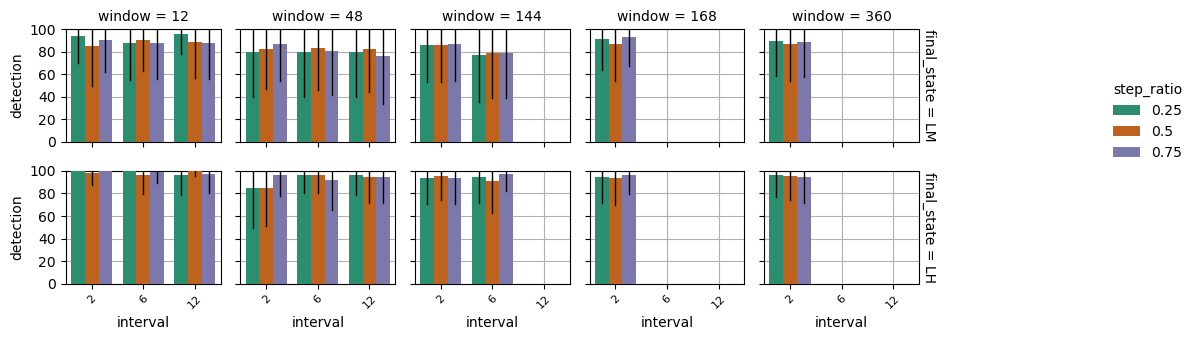

In [94]:
processed_detect_P2 = processed_detect[(processed_detect['step_ratio'] != .444) & (processed_detect['step_ratio'] != .333) & (processed_detect['step_ratio'] != .667)]

processed_detect_P2 = processed_detect_P2[(processed_detect_P2['window'] != 6) & (processed_detect_P2['interval'] != 3) & (processed_detect_P2['window'] != 84)].rename(columns = {'correct_%' : 'detection'})

processed_detect_P2 = processed_detect_P2[(processed_detect_P2['period_tgt'] == 'Targeted') & 
                                                            (processed_detect_P2['epochs_tgt'] == 'all') & 
                                                            (processed_detect_P2['skip_tgt'] == True)]

x_var = 'interval'
y_var = 'detection'
hue_var = 'step_ratio'

col_var = 'window'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = processed_detect_P2, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))

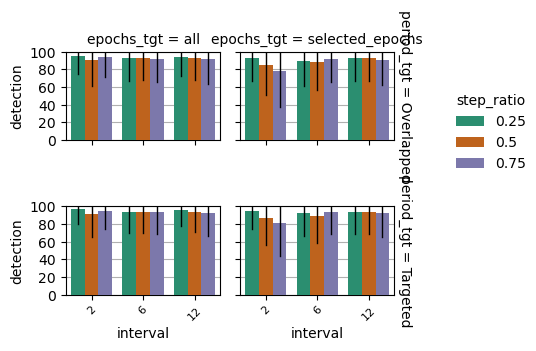

In [135]:
processed_detect_P2 = processed_detect[(processed_detect['step_ratio'] != .444) & (processed_detect['step_ratio'] != .333) & (processed_detect['step_ratio'] != .667)]

processed_detect_P2 = processed_detect_P2[(processed_detect_P2['window'] != 6) & (processed_detect_P2['interval'] != 3) & (processed_detect_P2['window'] != 84)].rename(columns = {'correct_%' : 'detection'})


processed_detect_P2 = processed_detect_P2[(processed_detect_P2['skip_tgt'] == True) & (processed_detect_P2['window'] == 12)]

x_var = 'interval'
y_var = 'detection'
hue_var = 'step_ratio'

col_var = 'epochs_tgt'
row_var = 'period_tgt'

row_order = None#['LM', 'LH']

plot_grid(data = processed_detect_P2, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))

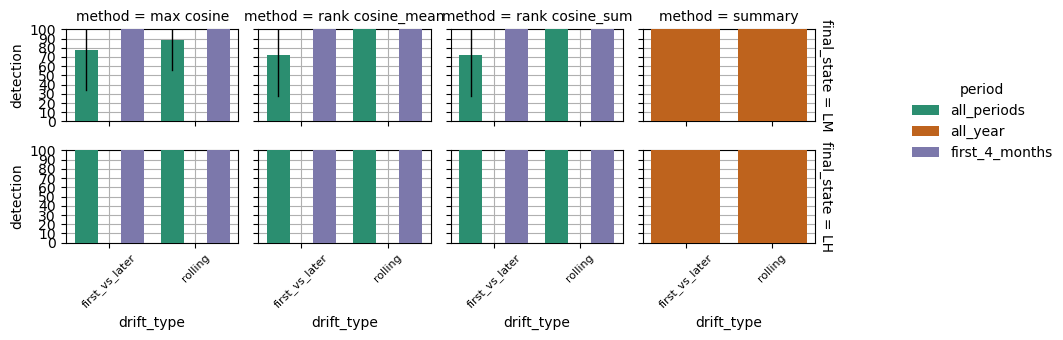

In [30]:
processed_detect_P2_selected = processed_detect_P2[(processed_detect_P2['window'] == 12) & (processed_detect_P2['interval'] == 2) & (processed_detect_P2['step_ratio'] == .25)]

processed_detect_P2_selected = processed_detect_P2_selected[(processed_detect_P2_selected['period_tgt'] == 'Targeted') & 
                                                            (processed_detect_P2_selected['epochs_tgt'] == 'all') & 
                                                            (processed_detect_P2_selected['skip_tgt'] == True)].rename(columns = {'correct_%' : 'detection'})



x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['LM', 'LH']

plot_grid(data = processed_detect_P2_selected, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))

In [65]:
df_detect_hyper.head()

,state_map,period,drift_type,wrong_%,correct_%,setup,method,skip_tgt,epochs_tgt,period_tgt,detection,exp_id
0,LL_LH__LH_LL_LL_LL_LM,all_periods,first_vs_later,33.33,66.67,12_2_14400_10_0.1,max cosine,True,init,Overlapped,1,HYPER
1,LL_LH__LH_LL_LL_LL_LM,all_periods,rolling,33.33,66.67,12_2_14400_10_0.1,max cosine,True,init,Overlapped,1,HYPER
2,LL_LH__LH_LL_LL_LL_LM,first_4_months,first_vs_later,0.00,100.00,12_2_14400_10_0.1,max cosine,True,init,Overlapped,1,HYPER
3,LL_LH__LH_LL_LL_LL_LM,first_4_months,rolling,0.00,100.00,12_2_14400_10_0.1,max cosine,True,init,Overlapped,1,HYPER
4,LL_LH__LH_LL_LL_LL_LM,first_year,first_vs_later,33.33,66.67,12_2_14400_10_0.1,max cosine,True,init,Overlapped,1,HYPER


window [12]
step_size [2]
interval [4]
lstm [10, 30, 40, 60]
info [0.1, 0.4, 0.05, 0.2]
ground_truth ['B', 'C', 'D', 'E', 'A']
final_state ['LH', 'LM']
similar_districts ['A', 'B', 'C', 'D', 'E']
com_epoch [10, 5]


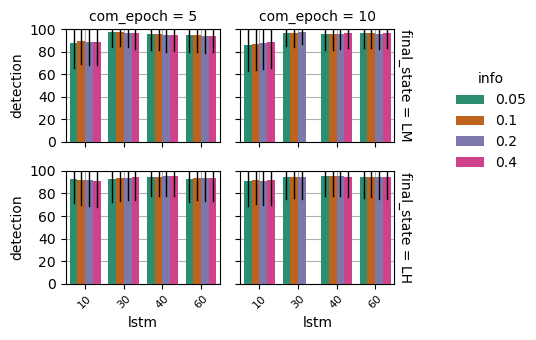

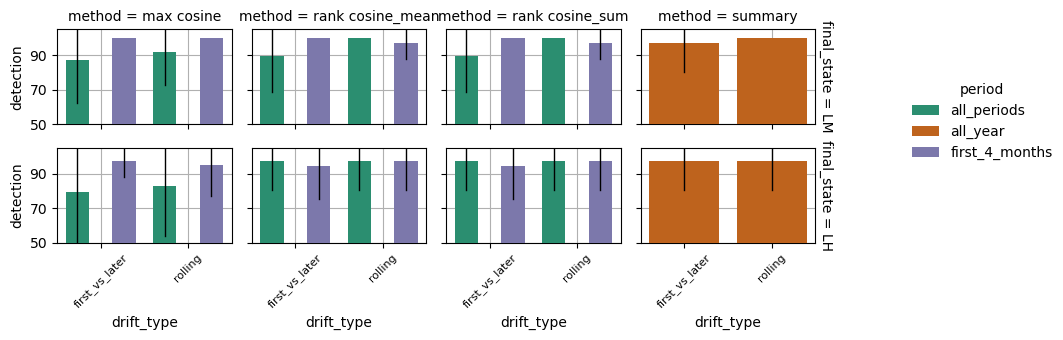

In [143]:
import glob
import os
import pandas as pd

# Step 1: Get all matching directories
# base_path = 'results/income_base/traceback/HYPER_INCOME'
base_path = 'results/density_base/traceback/HYPER'
pattern = os.path.join(base_path, '*2_*/')
directories = [d for d in glob.glob(pattern) if os.path.isdir(d)]

# Step 2: Count files in each directory

aux_det = []
aux_sim = []
aux_summ = []
for dir_path in directories:
    files = [f for f in glob.glob(os.path.join(dir_path, '*')) if os.path.isfile(f)]
    det = pd.read_csv(f'{dir_path}/compiled_detection.csv')
    sim = pd.read_csv(f'{dir_path}/compiled_similarity.csv')
    summ = pd.read_csv(f'{dir_path}/df_summary.csv')

    if len(summ['com_epoch'].unique()) != 1:
        raise ValueError('value should be unique!')

    summ['state_map'] = summ['exp_id']
    
    det = pd.merge(det, summ[['state_map', 'ground_truth','final_state', 'similar_districts', 'com_epoch']],
                  how = 'left', on = 'state_map')

    aux_det.append(det)
    aux_sim.append(sim)
    aux_summ.append(summ)

df_detect_hyper = pd.concat(aux_det, ignore_index=True)


processed_detect_hyper = df_detect_hyper.copy()
processed_detect_hyper[['window', 'step_size', 'interval', 'lstm', 'info']] = processed_detect_hyper['setup'].str.split('_', expand = True).astype(float)

for c in ['window', 'step_size', 'interval', 'lstm']:
    processed_detect_hyper[c] = processed_detect_hyper[c].astype(int)
    
processed_detect_hyper['interval'] = (processed_detect_hyper['interval'] / 3600).astype(int)
processed_detect_hyper['step_ratio'] = round(processed_detect_hyper['step_size']  / processed_detect_hyper['window'], 3)


processed_detect_hyper['init_state'] = processed_detect_hyper['state_map'].str[:2]
processed_detect_hyper['final_state'] = processed_detect_hyper['state_map'].str[3:5]

processed_detect_hyper.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

for c in ['window', 'step_size', 'interval', 'lstm', 'info', 'ground_truth','final_state', 'similar_districts', 'com_epoch']:
    print(c, processed_detect_hyper[c].unique().tolist())
    
plot_detect_hyper = processed_detect_hyper.copy()
plot_detect_hyper['detection'] = plot_detect_hyper['correct_%']


plot_detect_hyper = plot_detect_hyper[(plot_detect_hyper['period_tgt'] == 'Targeted') & 
                                                            (plot_detect_hyper['epochs_tgt'] == 'all') & 
                                                            (plot_detect_hyper['skip_tgt'] == True)]


x_var = 'lstm'
y_var = 'detection'
hue_var = 'info'

col_var = 'com_epoch'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = plot_detect_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))



processed_detect_hyper_selected = processed_detect_hyper[(processed_detect_hyper['lstm'] == 30) & (processed_detect_hyper['info'] == 0.4)].copy()

processed_detect_hyper_selected = processed_detect_hyper_selected[(processed_detect_hyper_selected['period_tgt'] == 'Targeted') & 
                                                            (processed_detect_hyper_selected['epochs_tgt'] == 'all') & 
                                                            (processed_detect_hyper_selected['skip_tgt'] == True)]

processed_detect_hyper_selected['detection'] = processed_detect_hyper_selected['correct_%']


x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['LM', 'LH']

plot_grid(data = processed_detect_hyper_selected, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (50,105))

window [12]
step_size [2]
interval [4]
lstm [10, 30, 40, 60]
info [0.1, 0.4, 0.05, 0.2]
ground_truth ['B', 'C', 'D', 'E', 'A']
final_state ['LH', 'LM']
similar_districts ['A', 'B', 'C', 'D', 'E']
com_epoch [10, 5]


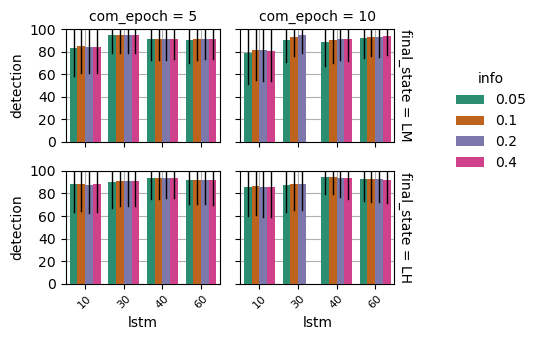

In [147]:
import glob
import os
import pandas as pd

# Step 1: Get all matching directories
# base_path = 'results/income_base/traceback/HYPER_INCOME'
base_path = 'results/density_base/traceback/HYPER'
pattern = os.path.join(base_path, '*2_*/')
directories = [d for d in glob.glob(pattern) if os.path.isdir(d)]

# Step 2: Count files in each directory

aux_det = []
aux_sim = []
aux_summ = []
for dir_path in directories:
    files = [f for f in glob.glob(os.path.join(dir_path, '*')) if os.path.isfile(f)]
    det = pd.read_csv(f'{dir_path}/compiled_detection.csv')
    sim = pd.read_csv(f'{dir_path}/compiled_similarity.csv')
    summ = pd.read_csv(f'{dir_path}/df_summary.csv')

    if len(summ['com_epoch'].unique()) != 1:
        raise ValueError('value should be unique!')

    summ['state_map'] = summ['exp_id']
    
    det = pd.merge(det, summ[['state_map', 'ground_truth','final_state', 'similar_districts', 'com_epoch']],
                  how = 'left', on = 'state_map')

    aux_det.append(det)
    aux_sim.append(sim)
    aux_summ.append(summ)

df_detect_hyper = pd.concat(aux_det, ignore_index=True)


processed_detect_hyper = df_detect_hyper.copy()
processed_detect_hyper[['window', 'step_size', 'interval', 'lstm', 'info']] = processed_detect_hyper['setup'].str.split('_', expand = True).astype(float)

for c in ['window', 'step_size', 'interval', 'lstm']:
    processed_detect_hyper[c] = processed_detect_hyper[c].astype(int)
    
processed_detect_hyper['interval'] = (processed_detect_hyper['interval'] / 3600).astype(int)
processed_detect_hyper['step_ratio'] = round(processed_detect_hyper['step_size']  / processed_detect_hyper['window'], 3)


processed_detect_hyper['init_state'] = processed_detect_hyper['state_map'].str[:2]
processed_detect_hyper['final_state'] = processed_detect_hyper['state_map'].str[3:5]

processed_detect_hyper.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

for c in ['window', 'step_size', 'interval', 'lstm', 'info', 'ground_truth','final_state', 'similar_districts', 'com_epoch']:
    print(c, processed_detect_hyper[c].unique().tolist())
    
plot_detect_hyper = processed_detect_hyper.copy()
plot_detect_hyper['detection'] = plot_detect_hyper['correct_%']

x_var = 'lstm'
y_var = 'detection'
hue_var = 'info'

col_var = 'com_epoch'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = plot_detect_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))

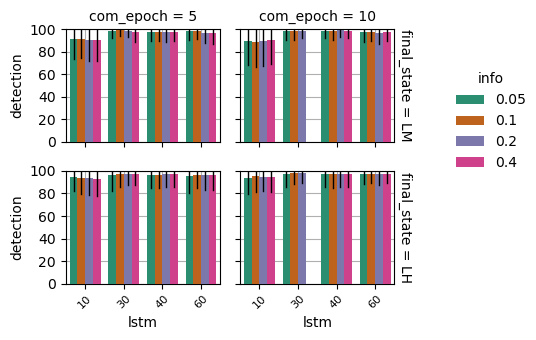

In [106]:
plot_detect_hyper_A = processed_detect_hyper.copy()

plot_detect_hyper_A = plot_detect_hyper_A[plot_detect_hyper_A['ground_truth'] == 'A']
plot_detect_hyper_A['detection'] = plot_detect_hyper_A['correct_%']

plot_detect_hyper_A = plot_detect_hyper_A[(plot_detect_hyper_A['period_tgt'] == 'Targeted') & 
                                                            (plot_detect_hyper_A['epochs_tgt'] == 'all') & 
                                                            (plot_detect_hyper_A['skip_tgt'] == True)]

x_var = 'lstm'
y_var = 'detection'
hue_var = 'info'

col_var = 'com_epoch'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = plot_detect_hyper_A, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,100))

In [224]:
2/12

0.16666666666666666

In [215]:
processed_detect_hyper.head()

,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,detection,ground_truth,final_state,similar_districts,com_epoch,window,step_size,interval,lstm,info,step_ratio,init_state
0,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,B,LH,A,10,12,2,4,10,0.1,0.167,LL
1,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,B,LH,A,10,12,2,4,10,0.1,0.167,LL
2,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,B,LH,A,10,12,2,4,10,0.1,0.167,LL
3,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,B,LH,A,10,12,2,4,10,0.1,0.167,LL
4,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,C,LH,A,10,12,2,4,10,0.1,0.167,LL


In [128]:
qwe = plot_detect_P2_selected.copy()
qwe[(qwe['period'] == 'all_periods') & (qwe['method'] == 'max cosine')]

,final_state,epochs_tgt,skip_tgt,period,period_tgt,drift_type,method,correct_%,count,detection
0,LH,all,True,all_periods,Targeted,first_vs_later,max cosine,900.0,9,100.000000
3,LH,all,True,all_periods,Targeted,rolling,max cosine,900.0,9,100.000000
14,LM,all,True,all_periods,Targeted,first_vs_later,max cosine,700.0,9,77.777778
17,LM,all,True,all_periods,Targeted,rolling,max cosine,800.0,9,88.888889


In [18]:
for c in ['epochs_tgt', 'skip_tgt',
          'period', 'period_tgt',
          'drift_type', 'method']:
    print(c, plot_detect_P2_selected[c].unique())

epochs_tgt ['all']
skip_tgt [ True]
period ['all_periods' 'all_year' 'first_4_months']
period_tgt ['Targeted']
drift_type ['first_vs_later' 'rolling']
method ['max cosine' 'rank cosine_mean' 'rank cosine_sum' 'summary']


In [53]:
df_detect_income = pd.read_csv(f'results/income_base/traceback/INCOMESIMPLE/compiled_detection.csv')

processed_detect_income = df_detect_income.copy()
processed_detect_income[['window', 'step_size', 'interval']] = processed_detect_income['setup'].str.split('_', expand = True).astype(int)

processed_detect_income['interval'] = (processed_detect_income['interval'] / 3600).astype(int)
processed_detect_income['step_ratio'] = round(processed_detect_income['step_size']  / processed_detect_income['window'], 3)


processed_detect_income['init_state'] = processed_detect_income['state_map'].str[:2]
processed_detect_income['final_state'] = processed_detect_income['state_map'].str[3:5]

processed_detect_income.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

processed_detect_income.head()

,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,detection,window,step_size,interval,step_ratio,init_state,final_state
0,all_periods,first_vs_later,33.33,66.67,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
1,all_periods,rolling,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
2,first_4_months,first_vs_later,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
3,first_4_months,rolling,33.33,66.67,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
4,first_year,first_vs_later,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL


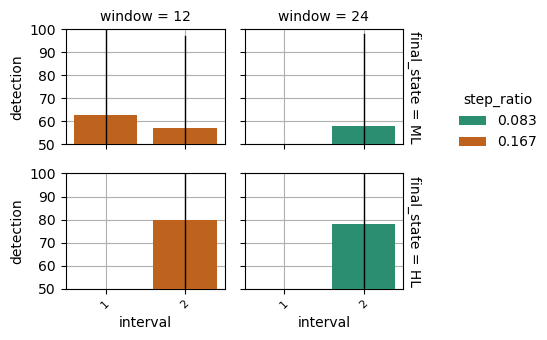

In [59]:
processed_detect_income_P2 = processed_detect_income.copy()

processed_detect_income_P2['detection'] = processed_detect_income_P2['correct_%']

x_var = 'interval'
y_var = 'detection'
hue_var = 'step_ratio'

col_var = 'window'
row_var = 'final_state'

row_order = ['ML', 'HL']

plot_grid(data = processed_detect_income_P2, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (50,100))

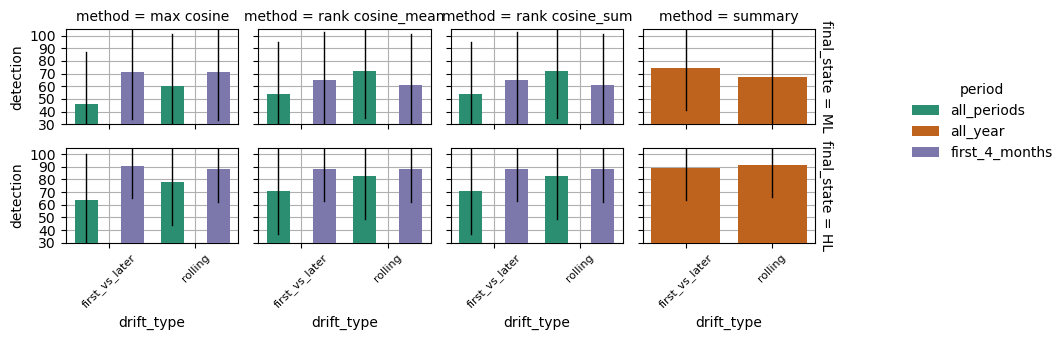

In [60]:
# plot_detect_income = processed_detect_income.groupby(['final_state', 'epochs_tgt', 'skip_tgt',  # epocas utilizadas
#                                                                  'period', 'period_tgt',    # meses (labels) considerados
#                                                                  'drift_type', 'method']  # tipo análise
#                                                               ).agg({
#                                                                 'correct_%' : 'sum',
#                                                                 'period' : 'count'
#                                                             }).rename(columns = {'period' : 'count'}).reset_index()

# plot_detect_income['detection'] = plot_detect_income['correct_%'] / plot_detect_income['count']

plot_detect_income = processed_detect_income.copy()
plot_detect_income['detection'] = plot_detect_income['correct_%']

plot_detect_income = plot_detect_income[(plot_detect_income['period_tgt'] == 'Targeted') & 
                                        (plot_detect_income['epochs_tgt'] == 'all') & 
                                        (plot_detect_income['skip_tgt'] == True)]

x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['ML', 'HL']

plot_grid(data = plot_detect_income, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (30,105))

In [67]:
import glob
import os
import pandas as pd

# Step 1: Get all matching directories
base_path = 'results/income_base/traceback/HYPER_INCOME'
# base_path = 'results/density_base/traceback/HYPER'
pattern = os.path.join(base_path, '*2_*/')
directories = [d for d in glob.glob(pattern) if os.path.isdir(d)]

# Step 2: Count files in each directory

aux_det = []
aux_sim = []

for dir_path in directories:
    files = [f for f in glob.glob(os.path.join(dir_path, '*')) if os.path.isfile(f)]
    det = pd.read_csv(f'{dir_path}/compiled_detection.csv')
    sim = pd.read_csv(f'{dir_path}/compiled_similarity.csv')

    aux_det.append(det)
    aux_sim.append(sim)

df_detect_hyper = pd.concat(aux_det, ignore_index=True)
df_detect_hyper.head()

,state_map,period,drift_type,wrong_%,correct_%,setup,method,skip_tgt,epochs_tgt,period_tgt,detection,exp_id
0,LL_HL__HL_LL_LL_LL_ML,all_periods,first_vs_later,33.33,66.67,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
1,LL_HL__HL_LL_LL_LL_ML,all_periods,rolling,40.00,60.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
2,LL_HL__HL_LL_LL_LL_ML,first_4_months,first_vs_later,0.00,100.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
3,LL_HL__HL_LL_LL_LL_ML,first_4_months,rolling,33.33,66.67,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
4,LL_HL__HL_LL_LL_LL_ML,first_year,first_vs_later,0.00,100.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME


In [69]:
processed_detect_hyper = df_detect_hyper.copy()
processed_detect_hyper[['window', 'step_size', 'interval', 'lstm', 'info']] = processed_detect_hyper['setup'].str.split('_', expand = True).astype(float)

for c in ['window', 'step_size', 'interval', 'lstm']:
    processed_detect_hyper[c] = processed_detect_hyper[c].astype(int)
    
processed_detect_hyper['interval'] = (processed_detect_hyper['interval'] / 3600).astype(int)
processed_detect_hyper['step_ratio'] = round(processed_detect_hyper['step_size']  / processed_detect_hyper['window'], 3)


processed_detect_hyper['init_state'] = processed_detect_hyper['state_map'].str[:2]
processed_detect_hyper['final_state'] = processed_detect_hyper['state_map'].str[3:5]

processed_detect_hyper.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

for c in ['window', 'step_size', 'interval', 'lstm', 'info']:
    print(c, processed_detect_hyper[c].unique().tolist())
    
processed_detect_hyper.head()

window [12, 48, 84]
step_size [2]
interval [4]
lstm [40, 10, 30, 60]
info [0.4, 0.2, 0.05, 0.1]


,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,detection,window,step_size,interval,lstm,info,step_ratio,init_state,final_state
0,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
1,all_periods,rolling,40.00,60.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
2,first_4_months,first_vs_later,0.00,100.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
3,first_4_months,rolling,33.33,66.67,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
4,first_year,first_vs_later,0.00,100.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL


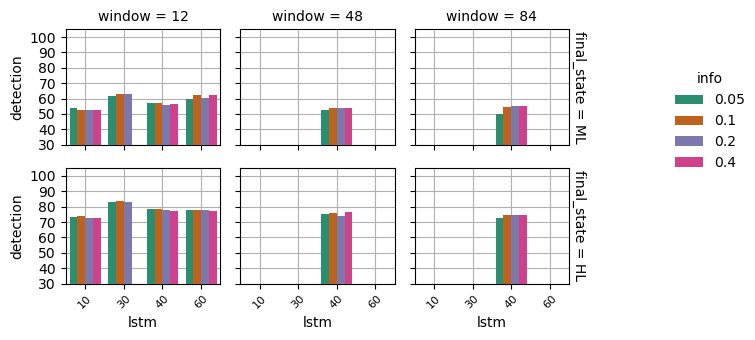

In [77]:
plot_detect_hyper = processed_detect_hyper.groupby(['final_state', 'window', 'lstm', 'info'] 
                                                              ).agg({
                                                                'correct_%' : 'sum',
                                                                'period' : 'count'
                                                            }).rename(columns = {'period' : 'count'}).reset_index()

plot_detect_hyper['detection'] = plot_detect_hyper['correct_%'] / plot_detect_hyper['count']

x_var = 'lstm'
y_var = 'detection'
hue_var = 'info'

col_var = 'window'
row_var = 'final_state'

row_order = ['ML', 'HL']

plot_grid(data = plot_detect_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (30,105))

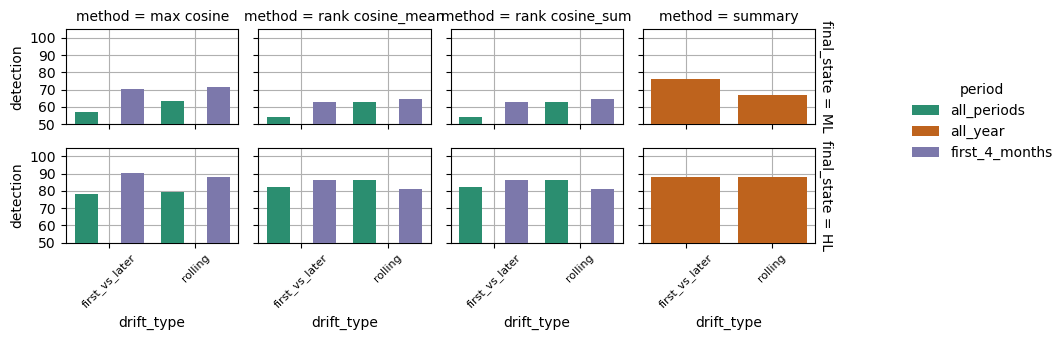

In [113]:
processed_detect_hyper_selected = processed_detect_hyper[(processed_detect_hyper['lstm'] == 30) & (processed_detect_hyper['info'] == 0.1)]

processed_detect_hyper_selected = processed_detect_hyper_selected[(processed_detect_hyper_selected['period_tgt'] == 'Targeted') & 
                                                            (processed_detect_hyper_selected['epochs_tgt'] == 'all') & 
                                                            (processed_detect_hyper_selected['skip_tgt'] == True)]


plot_detect_hyper_selected = processed_detect_hyper_selected.groupby(['final_state', 'epochs_tgt', 'skip_tgt',  # epocas utilizadas
                                                                 'period', 'period_tgt',    # meses (labels) considerados
                                                                 'drift_type', 'method']  # tipo análise
                                                              ).agg({
                                                                'correct_%' : 'sum',
                                                                'period' : 'count'
                                                            }).rename(columns = {'period' : 'count'}).reset_index()

plot_detect_hyper_selected['detection'] = plot_detect_hyper_selected['correct_%'] / plot_detect_hyper_selected['count']


x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['ML', 'HL']

plot_grid(data = plot_detect_hyper_selected, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (50,105))

In [115]:
plot_detect_hyper_selected[plot_detect_hyper_selected['final_state'] == 'ML'].sort_values(by = 'detection', ascending = False).head(5)

,final_state,epochs_tgt,skip_tgt,period,period_tgt,drift_type,method,correct_%,count,detection
20,ML,all,True,all_year,Targeted,first_vs_later,summary,1300.01,17,76.471176
25,ML,all,True,first_4_months,Targeted,rolling,max cosine,1216.66,17,71.568235
22,ML,all,True,first_4_months,Targeted,first_vs_later,max cosine,1200.01,17,70.588824
21,ML,all,True,all_year,Targeted,rolling,summary,1133.33,17,66.666471
26,ML,all,True,first_4_months,Targeted,rolling,rank cosine_mean,1100.00,17,64.705882


In [109]:
plot_detect_income[plot_detect_income['final_state'] == 'ML'].sort_values(by = 'detection', ascending = False).head(5)

,final_state,epochs_tgt,skip_tgt,period,period_tgt,drift_type,method,correct_%,count,detection
214,ML,all,True,all_year,Targeted,first_vs_later,summary,3800.05,51,74.510784
210,ML,all,True,all_periods,Targeted,rolling,rank cosine_mean,3683.37,51,72.222941
211,ML,all,True,all_periods,Targeted,rolling,rank cosine_sum,3683.37,51,72.222941
225,ML,all,True,first_4_months,Targeted,rolling,max cosine,3650.01,51,71.568824
222,ML,all,True,first_4_months,Targeted,first_vs_later,max cosine,3633.33,51,71.241765
